# Project 1: A fast Legendre transform by butterfly factorization

some words here

## Needed Imports

In [37]:
import sys
sys.path.append("starter_code/")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from legendre import legendre_vandermonde
from blocks import dyadic_blocks
from interp_decomp import interp_decomp

In [39]:
%matplotlib inline

## Part I: Build the Transform

some words here

### Task 1. Verify the structure exists.

In [31]:
# (1) The first thing we need is P itself. We can use the 'legendre_vandermonde'
#     function to do this.
N = 4096
P = legendre_vandermonde(N)

# (2) 
results = []
for level in [2, 4, 6]:
    blocks = dyadic_blocks(N, level)

    for block in blocks:
        row_start, row_end = block['rows']
        col_start, col_end = block['cols']

        rows = range(row_start, row_end)
        cols = range(col_start, col_end)

        A = P[rows][:, cols]
        sigma = np.linalg.svd(A, compute_uv=False)
        sigma_rel = sigma/sigma[0]

        for eps in [10e-3, 10e-6, 10e-9]:
            rank = np.sum(sigma_rel > eps)
            results.append({
                'level': level,
                'is_boundary': block['boundary'],
                'eps': eps,
                'rank': rank,
                'block_shape': A.shape,
            })

df_results = pd.DataFrame(results)

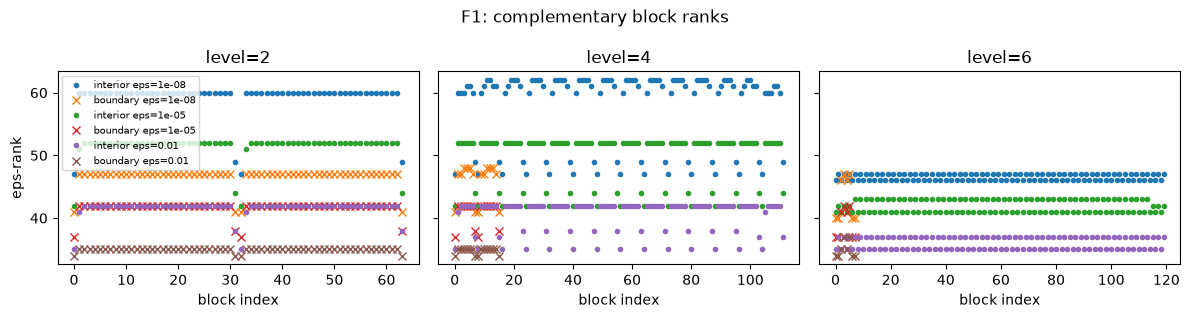

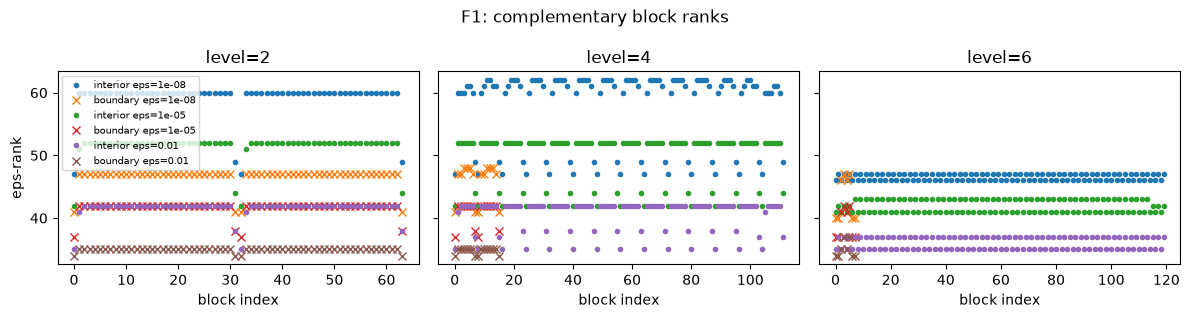

In [40]:
levels = sorted(df_results['level'].unique())
fig, axes = plt.subplots(1, len(levels), figsize=(4*len(levels), 3.2), sharey=True)

for ax, level in zip(axes, levels):
    sub = df[df['level'] == level]
    for eps in sorted(sub['eps'].unique()):
        s = sub[sub['eps'] == eps]
        interior = s[~s['is_boundary']]
        boundary = s[s['is_boundary']]
        ax.plot(range(len(interior)), interior['rank'], '.', label=f'interior eps={eps:g}')
        ax.plot(range(len(boundary)), boundary['rank'], 'x', label=f'boundary eps={eps:g}')
    ax.set_title(f'level={level}')
    ax.set_xlabel('block index')

axes[0].set_ylabel('eps-rank')
axes[0].legend(fontsize=7)
fig.suptitle('F1: complementary block ranks')
fig.tight_layout()
plt.show()

### Task 2. Build the factorization.